In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as py
import plotly.express as px
py.offline.init_notebook_mode(connected=True)

Feature Enginerring
        1->feature transformation
        2->feature Construction
        3->feature Selection
        4->Feature Extraction

1---> Feature Transformation
        a->missing value imputation
        b->handling categorical features
        c->outlier detection
        d->feature scaling

             Feature Scaling- Standardization (Day -24)

            Normalization

        1->Minmaxscaling
            Xi=(Xi-Xmin)/Xmax-Xmin

In [2]:

df=pd.read_csv('wine_data.csv')
df.columns=['Class label','Alcohol','Malic acid',5,6,7,8,9,10,11,12,13,14,15]
df=df[['Class label','Alcohol','Malic acid']]

<Axes: xlabel='Alcohol', ylabel='Density'>

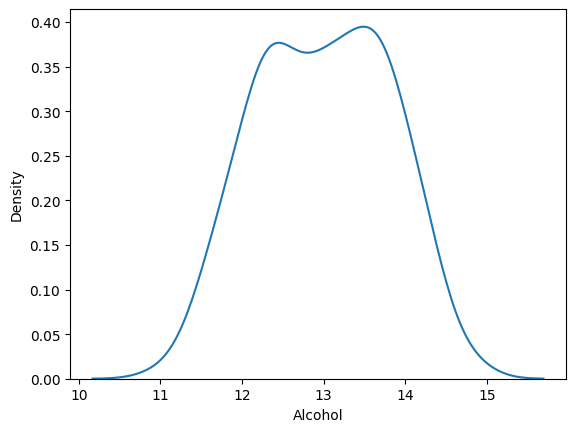

In [3]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

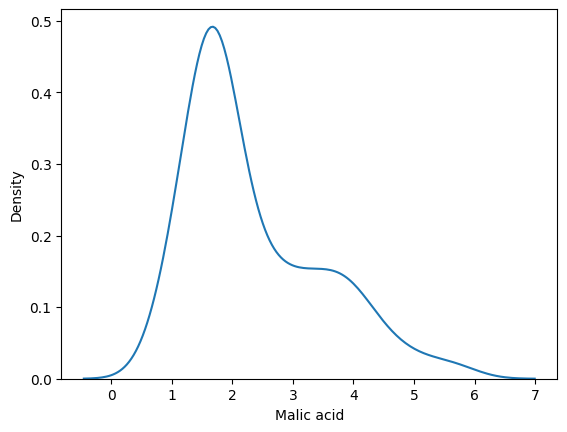

In [4]:
sns.kdeplot(df['Malic acid'])

In [5]:
px.scatter(df,color=df['Class label'],y=df['Malic acid'],x=df['Alcohol'],template='plotly_dark')

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('Class label',axis=1),
                                               df['Class label'],
                                               test_size=0.3,
                                               random_state=0)
x_train.shape,x_test.shape

((123, 2), (54, 2))

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

scaler.fit(x_train)
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [8]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [12]:
np.round(x_train.describe(),2)

,Alcohol,Malic acid
count,123.00,123.00
mean,12.98,2.33
std,0.78,1.17
min,11.03,0.89
25%,12.37,1.56
50%,13.05,1.83
75%,13.62,3.08
max,14.75,5.80


In [48]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic acid
count,123.0,123.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


Text(0.5, 1.0, 'After scaling')

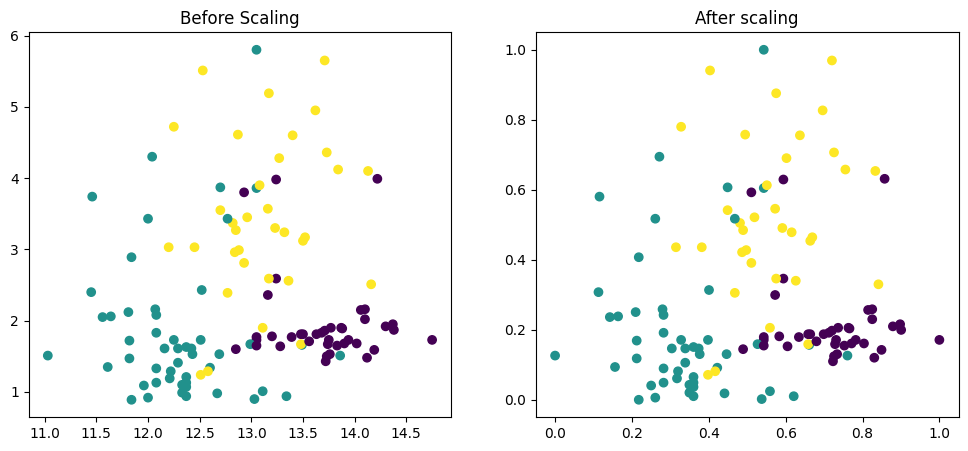

In [54]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['Alcohol'],x_train['Malic acid'],c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['Alcohol'],x_train_scaled['Malic acid'],c=y_train)
ax2.set_title('After scaling')

<Axes: title={'center': 'after scaling'}, xlabel='Alcohol', ylabel='Density'>

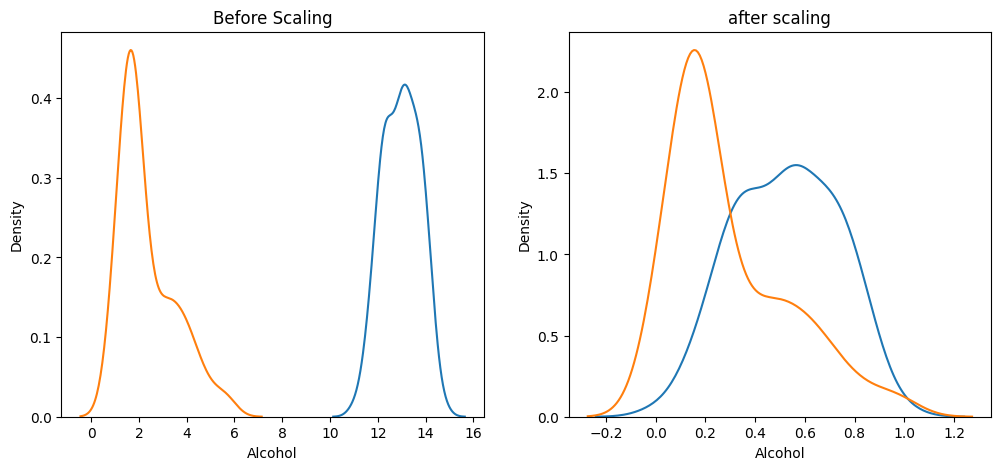

In [63]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
#before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Alcohol'],ax=ax1)
sns.kdeplot(x_train['Malic acid'],ax=ax1)

ax2.set_title("after scaling")
sns.kdeplot(x_train_scaled['Alcohol'],ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'],ax=ax2)

        Robust Scaling
        xi=(xi-xmedian)/IQR
        